# DWSIM Thermodynamic Import (prototype)

This notebook shows how to bring compound constants and ideal-gas heat
capacities from [DWSIM](https://dwsim.org) into difflow using
`difflow.dwsim_import`.

DWSIM is a .NET application reached from Python through `pythonnet`. Its calls
are **not** differentiable, so — like the Cantera and pyglenn importers — this
adapter uses DWSIM as a one-time data source and builds difflow's own JAX-native
structures. Unlike pyglenn, DWSIM **has critical properties**, so it feeds both
`SpeciesData` and `CriticalProperties` and can build a `CubicThermo` on its own.

> **Executable example.** DWSIM needs a .NET runtime, so this notebook runs
> against a small **mock** implementing the `DWSIMBackend` contract. All DWSIM
> contact is isolated in that backend; the import logic and everything
> downstream is the real difflow code. With DWSIM installed, pass `dtl_path=...`
> (or set `DWSIM_DTL_PATH`) instead of `backend=`.

In [1]:
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from difflow.dwsim_import import import_species_data, import_critical_props
from difflow.thermo import IdealThermo, CubicThermo
from difflow.eos import PengRobinson

## 1. A DWSIM backend (or a mock)

The real `DWSIMBackend` wraps `DWSIM.Thermodynamics.StandaloneLibrary.dll` and exposes `constants(name)` (MW, Tc, Pc, omega, Tb, Hf in difflow units) and `cp_ig_molar(name, T)` (J/mol/K). The mock returns the same contract.

In [2]:
# name -> (MW g/mol, Tc K, Pc Pa, omega, Tb K, Hf J/mol, cubic Cp J/mol/K)
_DB = {
    'Methane':        (16.04, 190.6, 4.60e6,  0.011, 111.7, -74600.0,  (33.0, 5.0e-3, 1.5e-5, -6.0e-9)),
    'Carbon dioxide': (44.01, 304.2, 7.38e6,  0.224, 194.7, -393500.0, (22.3, 5.98e-2, -3.5e-5, 7.5e-9)),
    'Water':          (18.02, 647.1, 22.06e6, 0.345, 373.1, -241800.0, (30.5, 9.6e-3, 1.2e-6, -1.1e-9)),
}

class MockDWSIMBackend:
    """Stand-in for DWSIMBackend using difflow-unit values."""
    def list_compounds(self):
        return list(_DB)
    def constants(self, name):
        MW, Tc, Pc, omega, Tb, Hf, _ = _DB[name]
        return dict(MW=MW, Tc=Tc, Pc=Pc, omega=omega, Tb=Tb, Hf=Hf)
    def cp_ig_molar(self, name, T):
        a, b, c, d = _DB[name][6]; T = float(T)
        return a + b*T + c*T**2 + d*T**3
    def close(self):
        pass

try:
    import clr  # pythonnet
    BACKEND = None       # adapter opens a real DWSIMBackend (needs dtl_path/DWSIM_DTL_PATH)
    SOURCE = 'real DWSIM via pythonnet'
except ImportError:
    BACKEND = MockDWSIMBackend()
    SOURCE = 'a mock of the DWSIMBackend contract (install pythonnet + DWSIM for real data)'
print('Data source:', SOURCE)

Data source: a mock of the DWSIMBackend contract (install pythonnet + DWSIM for real data)


## 2. Import `SpeciesData` and `CriticalProperties`

In [3]:
names = ['Methane', 'Carbon dioxide', 'Water']
sp = import_species_data(names, backend=BACKEND)
crit = import_critical_props(names, backend=BACKEND)
for n in names:
    print(f'{n:16s} MW={sp[n].MW:6.2f}  Tc={crit[n].Tc:6.1f} K  '
          f'Pc={crit[n].Pc/1e5:6.2f} bar  omega={crit[n].omega:.3f}  Hf={sp[n].Hf/1000:8.1f} kJ/mol')

Methane          MW= 16.04  Tc= 190.6 K  Pc= 46.00 bar  omega=0.011  Hf=   -74.6 kJ/mol
Carbon dioxide   MW= 44.01  Tc= 304.2 K  Pc= 73.80 bar  omega=0.224  Hf=  -393.5 kJ/mol
Water            MW= 18.02  Tc= 647.1 K  Pc=220.60 bar  omega=0.345  Hf=  -241.8 kJ/mol


## 3. Build a `CubicThermo` directly from DWSIM data

Because DWSIM supplies critical properties, one source gives both halves of the real-gas model.

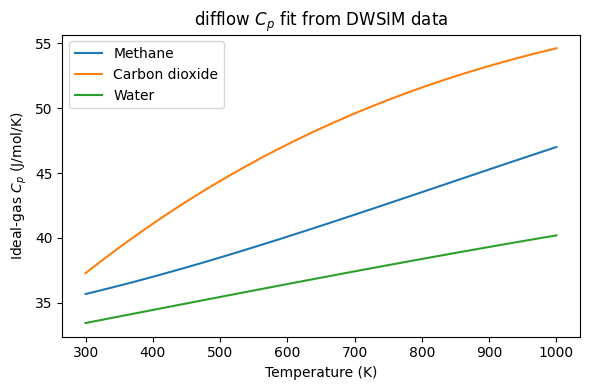

In [4]:
thermo = CubicThermo(IdealThermo(sp), PengRobinson(crit))
T = np.linspace(300, 1000, 60)
fig, ax = plt.subplots(figsize=(6, 4))
for n in names:
    ax.plot(T, [float(thermo.ideal.Cp(n, t)) for t in T], label=n)
ax.set_xlabel('Temperature (K)'); ax.set_ylabel('Ideal-gas $C_p$ (J/mol/K)')
ax.set_title('difflow $C_p$ fit from DWSIM data'); ax.legend()
plt.tight_layout(); plt.show()

In [5]:
flows = {'Methane': 1.0, 'Carbon dioxide': 1.0, 'Water': 1.0}
Tk, P = jnp.array(400.0), jnp.array(5e6)
H_ideal = thermo.stream_enthalpy(flows, Tk, P=None)
H_real = thermo.stream_enthalpy(flows, Tk, phase='vapor', P=P)
print(f'Ideal-gas enthalpy : {float(H_ideal):12.1f} W')
print(f'Real-gas (PR dep.) : {float(H_real):12.1f} W')
print(f'Departure          : {float(H_real - H_ideal):12.1f} W')

Ideal-gas enthalpy :      11150.7 W
Real-gas (PR dep.) :       6175.2 W
Departure          :      -4975.5 W


## Summary

- `difflow.dwsim_import` reads DWSIM compound constants and ideal-gas Cp into difflow `SpeciesData` + `CriticalProperties` (one-time; DWSIM is never in the gradient path).
- DWSIM provides critical properties, so it builds a `CubicThermo` on its own.
- **Prototype:** all DWSIM contact is isolated in `DWSIMBackend`; adapt it to your DWSIM version and pass via `backend=` if needed.